In [10]:
from pathlib import Path
import daspi as dsp
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon
import numpy as np
import pandas as pd
from daspi.constants import COLOR

IMAGE_DIR = Path.cwd().parent / 'docs' / 'img'
assert IMAGE_DIR.is_dir(), f'Image path {IMAGE_DIR} does not exist.'
DPI = 120

In [2]:
df = dsp.load_dataset('grnr_adjustment')
gage = dsp.GageEstimator(
    samples=df['result_gage'],
    reference=df['reference'][0],
    u_cal=df['U_cal'][0],
    tolerance=df['tolerance'][0],
    resolution=df['resolution'][0]
)

# Get metrics from describe
desc = gage.describe()
desc

c:\Appl\Python\.virtualenvs\DataScience-DY0ovQ8g-3.13\Lib\site-packages\daspi\statistics\estimation.py:583: UserWarning: NaN values found in the samples. These will be omitted from the analysis.
  warnings.warn(
c:\Appl\Python\.virtualenvs\DataScience-DY0ovQ8g-3.13\Lib\site-packages\daspi\statistics\estimation.py:583: UserWarning: NaN values found in the samples. These will be omitted from the analysis.
  warnings.warn(


,result_gage
n_samples,6.000000e+01
n_missing,6.000000e+00
n_outlier,0.000000e+00
min,1.000700e+00
max,1.001600e+00
R,9.000000e-04
mean,1.000809e+00
median,1.000800e+00
std,1.306999e-04
sem,1.778600e-05


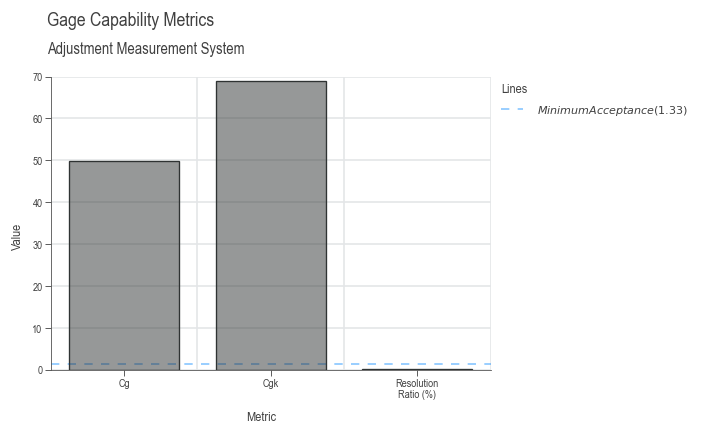

In [3]:
# Create DataFrame for plotting
df_cap = pd.DataFrame({
    'Metric': ['Cg', 'Cgk', 'Resolution\nRatio (%)'],
    'Value': [
        float(desc.loc['cg'].iloc[0]),
        float(desc.loc['cgk'].iloc[0]),
        float(desc.loc['resolution_ratio'].iloc[0]) * 100
    ]
})

# Create chart using native DaSPi plotting with stripes
acceptance_line = dsp.StripeLine(
    label='Minimum Acceptance (1.33)',
    position=1.33,
    orientation='horizontal',
    color=dsp.COLOR.SPECIAL_LINE,
    linestyle=dsp.LINE.DASHED,
    # width=2
)

chart = dsp.SingleChart(
        source=df_cap,
        target='Value',
        feature='Metric',
        categorical_feature=True,
    ).plot(
        dsp.Bar
    ).stripes(
        stripes=[acceptance_line]
    ).label(
        fig_title='Gage Capability Metrics',
        sub_title='Adjustment Measurement System',
        feature_label='Metric',
        target_label='Value'
    ).save(
        IMAGE_DIR / 'gage_capability_metrics.png',
        dpi=DPI,)

In [4]:
df = dsp.load_dataset('grnr_layer_thickness')
gage_study = dsp.GageStudyModel(
    source=df,
    target='result_gage',
    reference='reference',
    u_cal=df['U_cal'][0],
    tolerance=df['tolerance'][0],
    resolution=df['resolution'][0]
)

model = dsp.GageRnRModel(
    source=df,
    target='result_rnr',
    part='part',
    gage=gage_study,
    u_av='operator'
)
model

c:\Appl\Python\.virtualenvs\DataScience-DY0ovQ8g-3.13\Lib\site-packages\daspi\statistics\estimation.py:583: UserWarning: NaN values found in the samples. These will be omitted from the analysis.
  warnings.warn(
c:\Appl\Python\.virtualenvs\DataScience-DY0ovQ8g-3.13\Lib\site-packages\daspi\statistics\estimation.py:583: UserWarning: NaN values found in the samples. These will be omitted from the analysis.
  warnings.warn(


Model summary:
   hierarchical least_parameter   p_least         s         aic        r2  \
0          True   part:operator  0.918345  0.000904 -652.398296  0.984886   

     r2_adj   r2_pred  
0  0.970275  0.939543  

Analysis of variance:
Typ-I          DF            SS            MS           F             p  \
Source                                                                    
part            9  1.587817e-03  1.764241e-04  216.029478  9.218176e-25   
operator        2  8.333333e-07  4.166667e-07    0.510204  6.054889e-01   
part:operator  18  7.833333e-06  4.351852e-07    0.532880  9.183453e-01   
Residual       30  2.450000e-05  8.166667e-07         NaN           NaN   

Typ-I                n2  
Source                   
part           0.979539  
operator       0.000514  
part:operator  0.004832  
Residual       0.015114  

Repeatability and reproducibility (R&R):
                 MS  MS/Total         s        6s  6s/Total  6s/Tolerance
R&R    6.736111e-07   0.02248  0.000821  0.004924  0.149932      0.164148
EV     6.736111e-07   0.02248  0.000821  0.004924  0.149932      0.164148
AV     0.000000e+00   0.00000  0.000000  0.000000  0.000000      0.000000
PV     2.929174e-05   0.97752  0.005412  0.032473  0.988696      1.082437
Total  2.996535e-05   1.00000  0.005474  0.032844  1.000000      1.094812

Measurement uncertainty budget measuring system:
                u         U         Q  rank
CAL      0.000100  0.000200  0.013333   5.0
RE       0.000289  0.000577  0.038490   3.0
BI       0.000196  0.000393  0.026173   4.0
LIN      0.000000  0.000000  0.000000   NaN
EVR      0.000688  0.001377  0.091785   2.0
MS_REST  0.000000  0.000000  0.000000   NaN
MS       0.000723  0.001446  0.096371   NaN

Measurement uncertainty budget measuring process:
                u         U         Q  rank
EVO      0.000821  0.001641  0.109432   1.0
AV       0.000000  0.000000  0.000000   NaN
GV       0.000000  0.000000  0.000000   NaN
IA       0.000000  0.000000  0.000000   NaN
T        0.000000  0.000000  0.000000   NaN
STAB     0.000000  0.000000  0.000000   NaN
OBJ      0.000000  0.000000  0.000000   NaN
MP_REST  0.000000  0.000000  0.000000   NaN
MP       0.000850  0.001700  0.113305   NaN

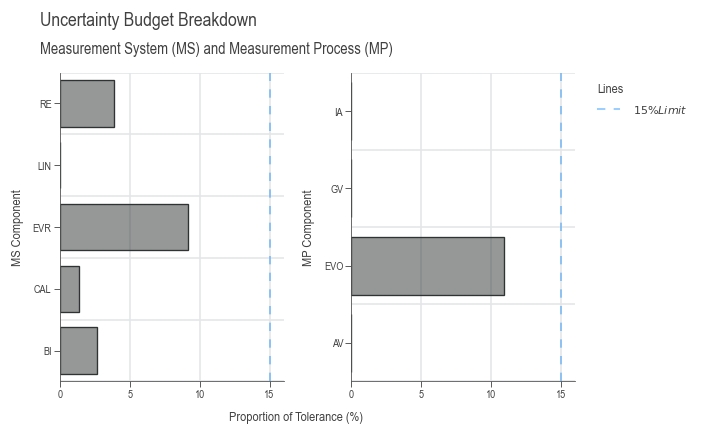

In [9]:
df_u = model.df_u

# Prepare data for MS components
ms_components = ['CAL', 'RE', 'BI', 'LIN', 'EVR']
df_ms = pd.DataFrame({
    'Component': ms_components,
    'Q': (df_u.loc[ms_components, 'Q'] * 100).values
})

# Prepare data for MP components
mp_components = ['EVO', 'AV', 'GV', 'IA']
df_mp = pd.DataFrame({
    'Component': mp_components,
    'Q': (df_u.loc[mp_components, 'Q'] * 100).values
})

# Create JointChart with two subplots and custom stripes
limit_line = dsp.StripeLine(
    label=r'15\% Limit',  # Use raw string with LaTeX escape
    position=15,
    orientation='vertical',
    color=dsp.COLOR.SPECIAL_LINE,
    linestyle=dsp.LINE.DASHED,
)

chart = dsp.JointChart(
        source=(df_ms, df_mp),
        target='Q',
        feature='Component',
        categorical_feature=True,
        ncols=2,
        nrows=1,
        target_on_y=False
    ).plot(
        dsp.Bar
    ).plot(
        dsp.Bar
    ).stripes(
        stripes=[limit_line]
    ).label(
        fig_title='Uncertainty Budget Breakdown',
        sub_title='Measurement System (MS) and Measurement Process (MP)',
        target_label='Proportion of Tolerance (%)',
        feature_label=('MS Component', 'MP Component')
    ).save(
        IMAGE_DIR / 'uncertainty_budget_breakdown.png',
        dpi=DPI,)

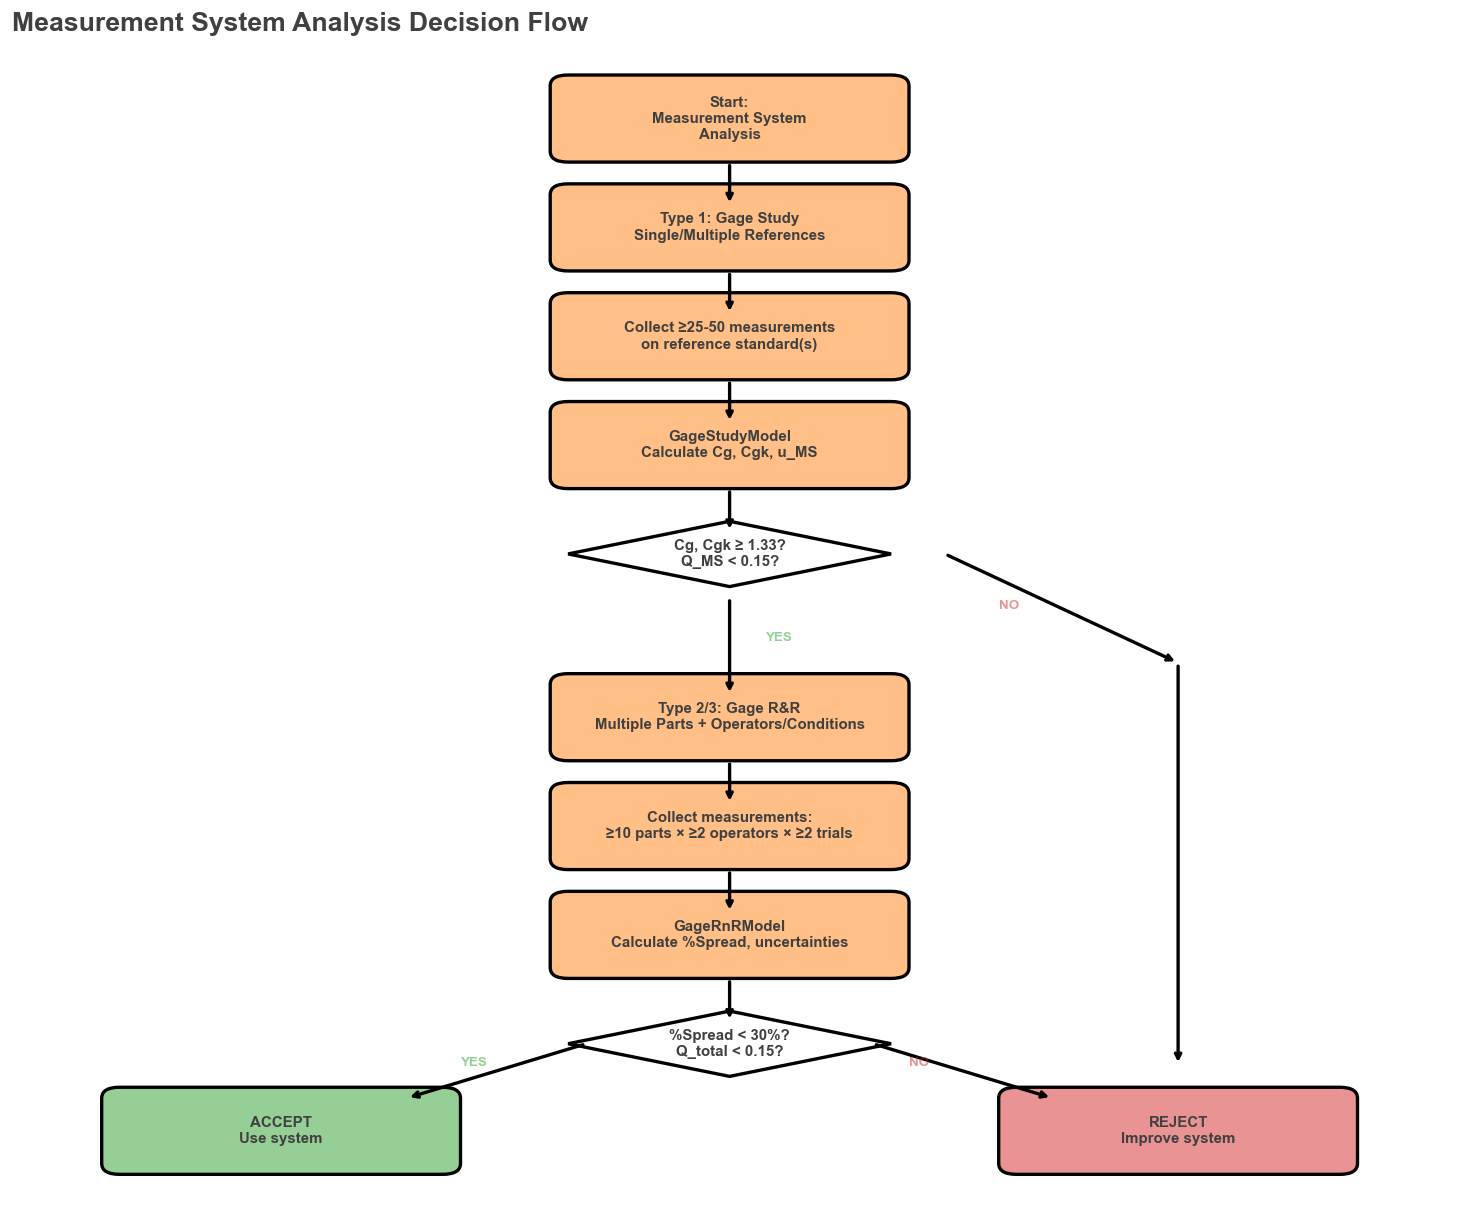

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')

# Get native DaSPi colors
good_color = COLOR.GOOD
bad_color = COLOR.BAD
process_color = COLOR.ANOMALY
decision_color = COLOR.TRANSPARENT

# Define boxes with positions and text
boxes = {
    'start': (0.5, 0.95, 'Start:\nMeasurement System\nAnalysis', 'process'),
    'type1': (0.5, 0.85, 'Type 1: Gage Study\nSingle/Multiple References', 'process'),
    'collect1': (0.5, 0.75, 'Collect ≥25-50 measurements\non reference standard(s)', 'process'),
    'analyze1': (0.5, 0.65, 'GageStudyModel\nCalculate Cg, Cgk, u_MS', 'process'),
    'decision1': (0.5, 0.55, 'Cg, Cgk ≥ 1.33?\nQ_MS < 0.15?', 'decision'),
    'type23': (0.5, 0.40, 'Type 2/3: Gage R&R\nMultiple Parts + Operators/Conditions', 'process'),
    'collect2': (0.5, 0.30, 'Collect measurements:\n≥10 parts × ≥2 operators × ≥2 trials', 'process'),
    'analyze2': (0.5, 0.20, 'GageRnRModel\nCalculate %Spread, uncertainties', 'process'),
    'decision2': (0.5, 0.10, '%Spread < 30%?\nQ_total < 0.15?', 'decision'),
    'accept': (0.25, 0.02, 'ACCEPT\nUse system', 'accept'),
    'reject': (0.75, 0.02, 'REJECT\nImprove system', 'reject'),
}

# Draw boxes
width, height = 0.18, 0.06
for key, (x, y, text, box_type) in boxes.items():
    if box_type == 'accept':
        color = good_color
        # Rounded rectangle
        patch = FancyBboxPatch((x - width/2, y - height/2), width, height,
                              boxstyle="round,pad=0.01", 
                              facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(patch)
    elif box_type == 'reject':
        color = bad_color
        # Rounded rectangle
        patch = FancyBboxPatch((x - width/2, y - height/2), width, height,
                              boxstyle="round,pad=0.01",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(patch)
    elif box_type == 'decision':
        # Diamond/rhombus shape for decisions
        color = decision_color
        diamond = Polygon([
            (x, y + height/2),           # top
            (x + width/2, y),            # right
            (x, y - height/2),           # bottom
            (x - width/2, y)             # left
        ], facecolor=color, edgecolor='black', linewidth=2, closed=True)
        ax.add_patch(diamond)
    else:
        # Process steps - rounded rectangles
        color = process_color
        patch = FancyBboxPatch((x - width/2, y - height/2), width, height,
                              boxstyle="round,pad=0.01",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(patch)
    
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            fontweight='bold', wrap=True)

# Draw arrows
arrows = [
    ((0.5, 0.91), (0.5, 0.87)),  # start -> type1
    ((0.5, 0.81), (0.5, 0.77)),  # type1 -> collect1
    ((0.5, 0.71), (0.5, 0.67)),  # collect1 -> analyze1
    ((0.5, 0.61), (0.5, 0.57)),  # analyze1 -> decision1
    ((0.5, 0.51), (0.5, 0.42)),  # decision1 -> type23 (YES)
    ((0.5, 0.36), (0.5, 0.32)),  # type23 -> collect2
    ((0.5, 0.26), (0.5, 0.22)),  # collect2 -> analyze2
    ((0.5, 0.16), (0.5, 0.12)),  # analyze2 -> decision2
    ((0.42, 0.10), (0.32, 0.05)), # decision2 -> accept (YES)
    ((0.58, 0.10), (0.68, 0.05)), # decision2 -> reject (NO)
    ((0.62, 0.55), (0.75, 0.45)), # decision1 -> improve (NO)
    ((0.75, 0.45), (0.75, 0.08)), # improve -> reject
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
               arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add YES/NO labels
ax.text(0.52, 0.47, 'YES', fontsize=8, color=good_color, fontweight='bold')
ax.text(0.65, 0.50, 'NO', fontsize=8, color=bad_color, fontweight='bold')
ax.text(0.35, 0.08, 'YES', fontsize=8, color=good_color, fontweight='bold')
ax.text(0.60, 0.08, 'NO', fontsize=8, color=bad_color, fontweight='bold')

ax.set_xlim(0.1, 0.9)
ax.set_ylim(-0.05, 1)
ax.set_title('Measurement System Analysis Decision Flow', 
             fontsize=16, fontweight='bold', pad=20)

plt.savefig(IMAGE_DIR / 'msa_decision_flow.png', dpi=DPI,)